# ZeroER feature space — t-SNE exploration (manual features vs. PLM embeddings)

manual features vs PLM embeddings (for starters)

1. **manual sim-features** — the live-pipeline per-pair similarity vector
   (`pyjedai_module._build_feature_matrix`, 6 string sims per attribute);

2. **3 sentence-transformers** — concat every attribute column of a record into
   one string, embed it, and represent each *pair* by `|u − v|` of the two
   L2-normalised record embeddings

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # ZeroER/ — for utils & pyjedai_module

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

from utils import DATASETS, load_data
from pyjedai_module import ZeroEREstimator, _build_feature_matrix

# --- config ---------------------------------------------------------------
DATASETS_TO_RUN = ["abt_buy", "amazon_googleproducts"]   # the two hard ones
PLM_MODELS = {                       # short name -> HF sentence-transformer id
    "sminilm":        "all-MiniLM-L12-v2",
    "smpnet":         "all-mpnet-base-v2",
    "sdistilroberta": "all-distilroberta-v1",
}
N_NEGATIVES = 3000          # non-matches embedded (all matches are always kept)
BLOCKER     = "standard"    # will experiment with PLM blocker as well at some point
SEED        = 0
OUT_DIR = os.path.abspath(os.path.join("..", "outputs", "tsne_notebook"))
os.makedirs(OUT_DIR, exist_ok=True)
print("cwd:", os.getcwd())
print("saving figures to:", OUT_DIR)

/home/mda4172/Projects/data-env/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Created embeddings directory at: /home/mda4172/Projects/pyJedAI/ZeroER/datasets/.embs
cwd: /home/mda4172/Projects/pyJedAI/ZeroER/datasets
saving figures to: /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook


## 1. Candidate pairs + gold labels

Positives = all gold matches. Negatives = the *hard* non-matches that survive
the blocker (what the matcher actually has to reject), subsampled to
`N_NEGATIVES`. The same pair set feeds all four panels, so they're comparable.

In [2]:
def gold_pairs(data):
    """Gold matches as positional (left_idx, right_idx) tuples into data.entities."""
    out = []
    for _, (lid, rid) in data.ground_truth.iterrows():
        if lid in data._ids_mapping_1 and rid in data._ids_mapping_2:
            out.append((data._ids_mapping_1[lid], data._ids_mapping_2[rid]))
    return out


def build_pairs_and_labels(data, n_negatives=N_NEGATIVES, blocker=BLOCKER, seed=SEED):
    gold = gold_pairs(data)
    gold_set = {frozenset(p) for p in gold}

    est = ZeroEREstimator(blocker=blocker)          # 'standard' => no PLM download
    blocks = est.build_blocks(data)
    cand = [(eid, c) for eid, cs in blocks.items() for c in cs]

    pos = [p for p in cand if frozenset(p) in gold_set]
    neg = [p for p in cand if frozenset(p) not in gold_set]
    kept = {frozenset(p) for p in pos}
    blocking_recall = len(kept) / max(len(gold_set), 1)   # upper bound on F1
    pos = pos + [p for p in gold if frozenset(p) not in kept]   # re-add dropped golds

    rng = np.random.default_rng(seed)
    if len(neg) > n_negatives:
        neg = [neg[i] for i in rng.choice(len(neg), n_negatives, replace=False)]

    pairs = pos + neg
    labels = np.concatenate([np.ones(len(pos), int), np.zeros(len(neg), int)])
    info = dict(blocking_recall=round(blocking_recall, 3), n_pos=len(pos), n_neg=len(neg))
    return pairs, labels, info

## 2. PLM embeddings

`tsne_2d` standardises, PCA-reduces high-dim PLM vectors to 50-D, then projects to 2-D. 
`manual_features` reuses the live pipeline;
`plm_pair_vectors` concatenates a record's columns, embeds, and forms `|u − v|` per pair.

In [3]:
def tsne_2d(X, seed=SEED):
    Xs = StandardScaler().fit_transform(X)
    if Xs.shape[1] > 50:                       # de-noise high-dim PLM space first
        Xs = PCA(n_components=50, random_state=seed).fit_transform(Xs)
    perp = max(5.0, min(30.0, (len(Xs) - 1) / 3.0))
    return TSNE(n_components=2, perplexity=perp, init="pca",
                learning_rate="auto", random_state=seed).fit_transform(Xs)


def manual_features(data, attrs, pairs):
    fm = _build_feature_matrix(pairs, data, attrs)   # rows aligned with `pairs`
    return fm.values, fm.shape[1]


_MODELS = {}
def _model(mid):
    if mid not in _MODELS:
        _MODELS[mid] = SentenceTransformer(mid)
    return _MODELS[mid]


def plm_pair_vectors(data, attrs, pairs, mid):
    """Concat all attribute columns -> one text per record -> embed -> |u-v| per pair."""
    texts = data.entities[attrs].astype(str).agg(" ".join, axis=1).to_numpy()
    used = sorted({i for p in pairs for i in p})     # embed only referenced records
    slot = {i: k for k, i in enumerate(used)}
    emb = np.asarray(_model(mid).encode([texts[i] for i in used],
                                        normalize_embeddings=True,
                                        batch_size=64, show_progress_bar=False))
    li = np.array([slot[a] for a, _ in pairs])
    ri = np.array([slot[b] for _, b in pairs])
    return np.abs(emb[li] - emb[ri]), emb.shape[1]

## 3. Plotting

In [4]:
def scatter(ax, coords, labels, title):
    neg, pos = coords[labels == 0], coords[labels == 1]
    ax.scatter(neg[:, 0], neg[:, 1], s=6, c="#9bb7d4", alpha=0.35,
               linewidths=0, label=f"non-match ({len(neg)})")
    ax.scatter(pos[:, 0], pos[:, 1], s=12, c="#d62728", alpha=0.8,
               linewidths=0, label=f"match ({len(pos)})")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=7, framealpha=0.8, markerscale=1.5)

## 4 · Run — 4 panels per dataset

Per dataset: build the shared pair set once, then t-SNE the manual features and
each PLM `|u−v|` space.

=== abt_buy ===


/home/mda4172/Projects/data-env/lib/python3.10/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


  1097 matches / 3000 non-matches | blocking recall 0.981


  embedding with sminilm (all-MiniLM-L12-v2) ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  embedding with smpnet (all-mpnet-base-v2) ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  embedding with sdistilroberta (all-distilroberta-v1) ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

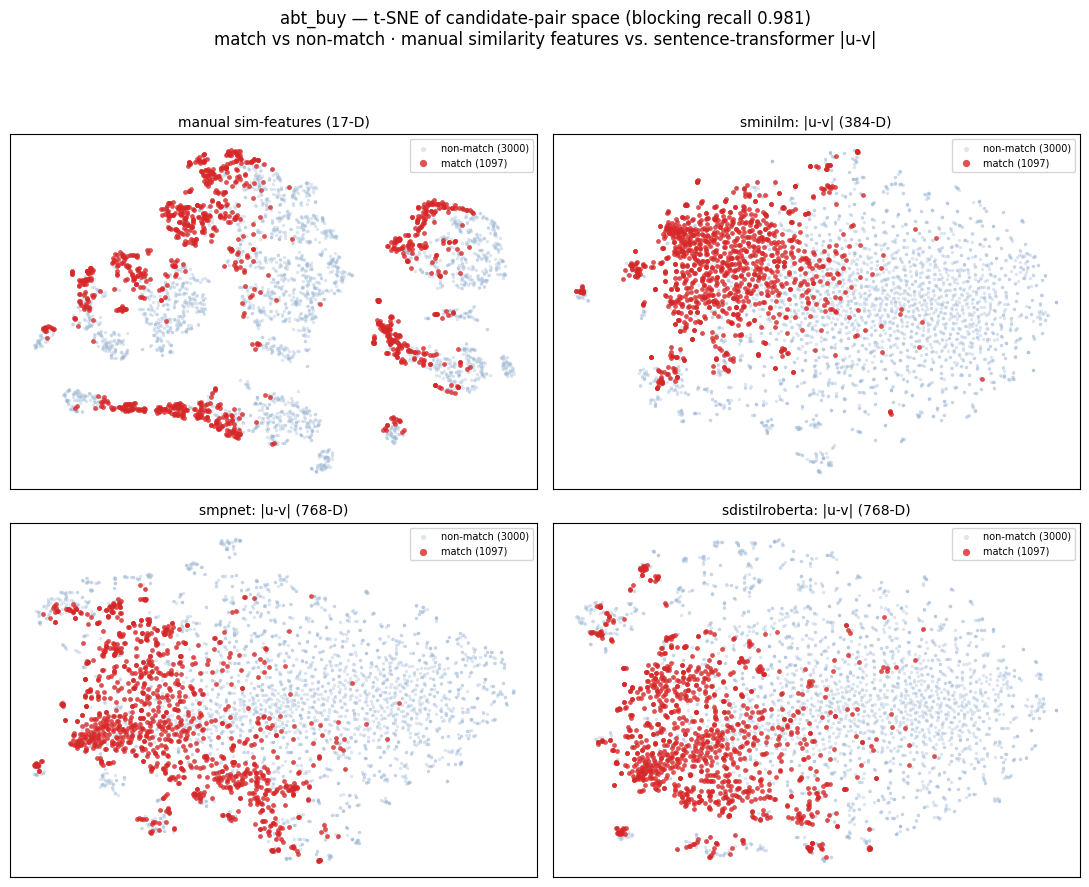

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne4_abt_buy.png


=== amazon_googleproducts ===


  1300 matches / 3000 non-matches | blocking recall 0.944


  embedding with sminilm (all-MiniLM-L12-v2) ...


  embedding with smpnet (all-mpnet-base-v2) ...


  embedding with sdistilroberta (all-distilroberta-v1) ...


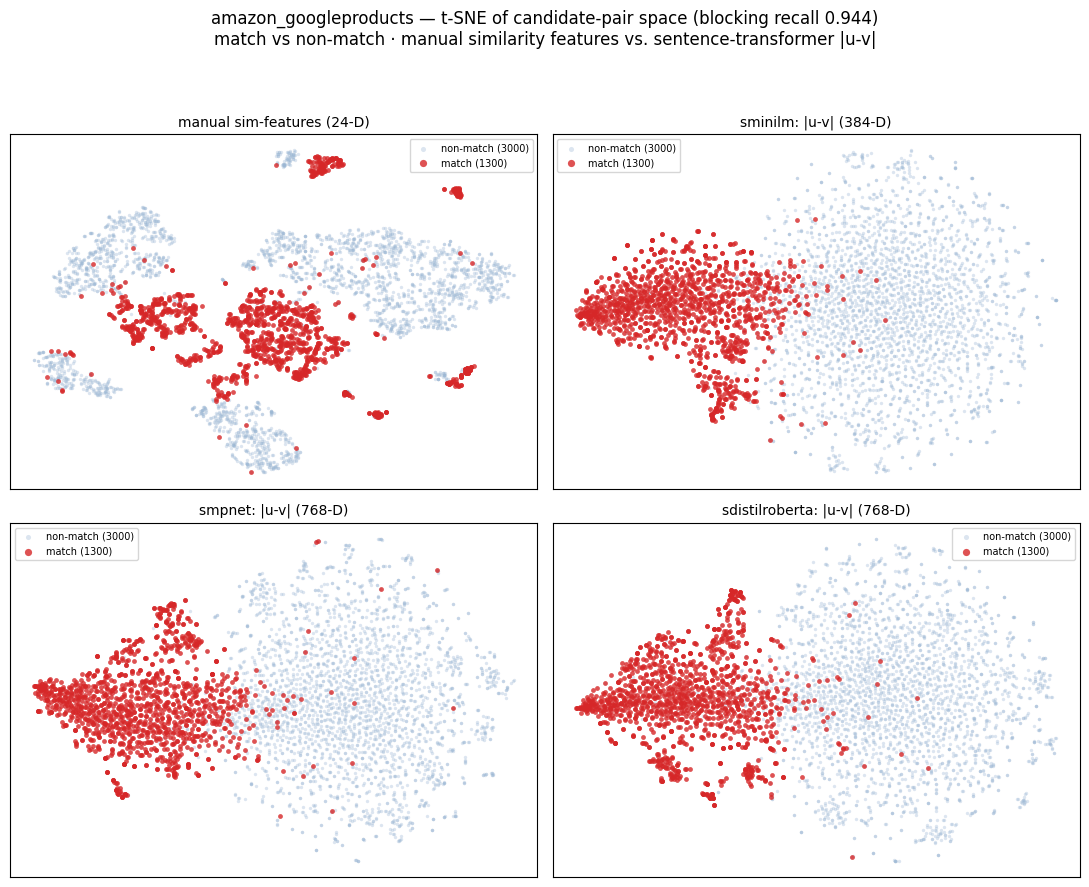

  saved /home/mda4172/Projects/pyJedAI/ZeroER/outputs/tsne_notebook/tsne4_amazon_googleproducts.png


In [5]:
for ds in DATASETS_TO_RUN:
    print(f"=== {ds} ===", flush=True)
    data = load_data(ds)
    attrs = DATASETS[ds]["attributes"]
    pairs, labels, info = build_pairs_and_labels(data)
    print(f"  {info['n_pos']} matches / {info['n_neg']} non-matches "
          f"| blocking recall {info['blocking_recall']}", flush=True)

    panels = []
    Xm, dim = manual_features(data, attrs, pairs)
    panels.append((f"manual sim-features ({dim}-D)", tsne_2d(Xm)))
    for short, mid in PLM_MODELS.items():
        print(f"  embedding with {short} ({mid}) ...", flush=True)
        Xp, dim = plm_pair_vectors(data, attrs, pairs, mid)
        panels.append((f"{short}: |u-v| ({dim}-D)", tsne_2d(Xp)))

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, (title, coords) in zip(axes.flat, panels):
        scatter(ax, coords, labels, title)
    fig.suptitle(f"{ds} — t-SNE of candidate-pair space "
                 f"(blocking recall {info['blocking_recall']})\n"
                 f"match vs non-match · manual similarity features vs. "
                 f"sentence-transformer |u-v|", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    out = os.path.join(OUT_DIR, f"tsne4_{ds}.png")
    fig.savefig(out, dpi=150)
    plt.show()
    print("  saved", out, flush=True)